In [1]:
import Agents
import Markets

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats

def add_price_data(df, t):
    
    #pA_buy, pA_sell, pB_buy, pB_sell = df
    p_buy, p_sell = df
    
    for v, agent in enumerate(agent_list):
        p_buy[t][v] = agent.p_buy
        p_sell[t][v] = agent.p_sell



In [2]:
def add_quant_data(df, t):

    for v,agent in enumerate(agent_list):

        df[t][v] = agent.Q
    
    
    #print(agent_list[0].Q)
    
def add_deficit_data(df, t):

    for v,agent in enumerate(agent_list):

        df[t][v] = agent.D
    
def add_money_data(df, t):
    
    for v,agent in enumerate(agent_list):

        df[t][v] = agent.M
    
    
def reset():
    
    for agent in agentA_list:
        
        if initialize_money=='random':
            agent.M = M_dict[agent]
        else:
            agent.M = M
        #    
        #if initialize_quantity=='random':
        #    agent.Q[0] = np.random.uniform(QA1)
        #else:
        #    agent.Q[0] = QA1

        if initialize_prices=='random':
            
            agent.p_buy  = np.random.uniform(agent.M, size=n)
            agent.p_sell = np.random.uniform(agent.M, size=n)
            
        else:
            agent.p_buy  = [p1buy_A_0, p2buy_A_0]
            agent.p_sell = [p1sell_A_0, p2sell_A_0]
        
    for agent in agentB_list:
        
        if initialize_money=='random':
            agent.M = M_dict[agent]
        else:
            agent.M = M
        
        if initialize_prices=='random':
            agent.p_buy  = np.random.uniform(agent.M, size=n)
            agent.p_sell = np.random.uniform(agent.M, size=n)
        
        else:
            agent.p_buy  = [p1buy_B_0, p2buy_B_0]
            agent.p_sell = [p1sell_B_0, p2sell_B_0]
    
    market.reset()


In [3]:
def market_supply_demand(*, i=0):

    dE_dict = market.set_intended_exchange(ExchangeDict)
    dE_dict

    supplied = 0
    demanded = 0
    for dE in dE_dict.values():
        if dE[i] < 0:
            supplied += dE[i]
        elif dE[i] > 0:
            demanded += dE[i]

    return -supplied, demanded

def plot_market(i, *, ps=10, log=False, supply_demand=False):

    f, ax = plt.subplots(1, figsize=(10,4)) #(2,1)

    ax.plot(ME_df[:,i], c='C0', label=f'$\Delta M_{i}$')
    ax.plot(QE_df[:,i], c='C1', label=f'$\Delta Q_{i}$')
    ax.plot(ntries_df, c='k', label='Tries', lw='0.5')

    p = ME_df[:,i]/QE_df[:,i]
    ax.scatter(np.arange(0,T-1), p, c='g', label=f'$p_{i}$', s=ps)
    
    if supply_demand:
        ax.plot(supply_df, c='blue', ls='--', label=f'Supply')
        ax.plot(demand_df, c='orange', ls='--', label=f'Demand')

    ax.legend()
    
    if log:
        plt.yscale('log')
        
    plt.title(f'Market for Commodity {i}')
    plt.xlabel('t')
    plt.ylabel('$M$, $Q$')


def plot_prices(p_df, i, *, A=0, B=1, ps=10, log=False, includeM=True):

    'A sells i=0 and buys i=1, and vice versa for B'

    if i == 0:
        plt.plot(p_df[1][:,A,i], c='C0', ls='-.', label=f"A's Selling Price for {i}")
        plt.plot(p_df[0][:,B,i], c='C1', ls='-', label=f"B's Buying Price for {i}")

    elif i == 1:
        plt.plot(p_df[0][:,A,i], c='C0', ls='-', label=f"A's Buying Price for {i}")
        plt.plot(p_df[1][:,B,i], c='C1', ls='-.', label=f"B's Selling Price for {i}")

    if includeM:
        plt.plot(M_df[:,A], c='C0', ls=':', lw=0.5, label=f'$M_A$')
        plt.plot(M_df[:,B], c='C1', ls=':', lw=0.5, label=f'$M_B$')
    
    p = ME_df[:,i]/QE_df[:,i]
    plt.scatter(np.arange(T-1)+0.5, p, c='g', s=ps)
    
    plt.legend()
    
    if log:
        plt.yscale('log')

    plt.title(f'Market Prices for Commodity {i}')
    plt.xlabel('t')
    plt.ylabel('Prices')
    
def plot_quantities(Q_df, D_df, i, *, A=0, B=1):

    plt.plot(Q_df[:,A,i], c='C0', ls='-', label=f"A's Q{i}")
    plt.plot(D_df[:,A,i], c='C0', ls=':', label=f"A's D{i}")

    plt.plot(Q_df[:,B,i], c='C1', ls='-', label=f"B's Q{i}")
    plt.plot(D_df[:,B,i], c='C1', ls=':', label=f"B's D{i}")

    plt.legend()

    plt.title(f'Quantities for Commodity {i}')
    plt.xlabel('t')
    plt.ylabel('Q,D')


In [4]:
NA = 10
NB = 2
N = NA+NB

initialize_money = 'random'
M = 100

n = 2

QA1 = 100
QA2 = 0

QB1 = 0
QB2 = 0

QA_0 = np.array([QA1, QA2])
QB_0 = np.array([QB1, QB2])

QA = np.copy(QA_0)
QB = np.copy(QB_0)

qA = np.array([0, 0])
qB = np.array([0, 0])

cA = np.array([0, 0])
cB = np.array([5, 0])

DA = cA.copy()
DB = cB.copy()

initialize_prices = 'random'

p1buy_A_0    = 0 
p1sell_A_0   = 10

p2buy_A_0    = 0 
p2sell_A_0   = 0 

p1buy_B_0    = 20
p1sell_B_0   = 0 

p2buy_B_0    = 0
p2sell_B_0   = 0

In [5]:
agentA_list = [Agents.Agent(QA.copy(), DA.copy(), M, n_actions=1, input_dims=[1]) for v in range(NA)]
agentB_list = [Agents.Agent(QB.copy(), DB.copy(), M, n_actions=1, input_dims=[1]) for v in range(NB)]

agent_list = agentA_list + agentB_list

In [6]:
M_dict = {}

for agent in agent_list:
    
    M_dict[agent] = np.random.uniform(M)

In [7]:
Q = np.zeros(n)
for agent in agent_list:
    Q += agent.Q
    
Q

array([1000.,    0.])

In [8]:
D = np.zeros(n)
for agent in agent_list:
    D += agent.D
    
D

array([10.,  0.])

In [9]:
S = np.zeros(n)
for agent in agent_list:
    S += (agent.Q - agent.D)
    
S

array([990.,   0.])

In [10]:
price_adjust_method = 'step_random'
max_agent_tries = 1000 #100

verbose = False

alpha = 0.1 #0.01     #0.05 #0.1/max_agent_tries
beta  = 0.1 #0.01      #0.01 #1.0/max_agent_tries #1./max_agent_tries
gamma = 1.00
epsilon_switch = 0.0
epsilon_rand =   0.0 #0.01/max_agent_tries

max_tries = N*max_agent_tries
 #_random' #proportional_random' #'step_random'
min_price = 1e-5

In [11]:
market = Markets.Market(n, 
                        verbose=verbose, 
                        minimum_price=min_price, 
                        alpha=alpha, 
                        beta=beta, 
                        gamma=gamma, 
                        epsilon_switch=epsilon_switch, 
                        epsilon_rand=epsilon_rand,
                        max_agent_tries=max_agent_tries, 
                        max_tries=max_tries,
                        price_adjust_method=price_adjust_method)

print(f'Market has {max_tries} max tries')

ExchangeDict = {agent : 2 for agent in agent_list}

Market has 12000 max tries


In [12]:
np.random.uniform(0,market.beta)
#market.beta

0.08105860075204004

In [13]:
T = 500 #100 #50

reset()

# Setup data
p_buy, p_sell = np.zeros((T, N, n)), np.zeros((T, N, n))
p_df = (p_buy, p_sell)

Q_df = np.zeros((T, N, n))

D_df = np.zeros((T, N, n))

M_df = np.zeros((T, N))

ME_df = np.zeros((T-1,n))
QE_df = np.zeros((T-1,n))
sE_df = np.zeros((T-1,n))
ntries_df = []

supply_df = []
demand_df = []

add_price_data(p_df, 0)
add_quant_data(Q_df, 0)
add_deficit_data(D_df, 0)
add_money_data(M_df, 0)

# Run market
for t in range(T-1):
 
    supply0, demand0 = market_supply_demand()

    ME, QE, stn_dev, ntries = market.run_exchange(ExchangeDict)
    
    # Reset quantities
    for agentA in agentA_list:
        #pass
        #agentA.Q = np.maximum(np.zeros(n), agentA.Q + qA - cA) #np.array([QA1, QA2])*np.exp(-0.005*t)
        
        agentA.Q = QA.copy()
        
        if initialize_money == 'random':
            agentA.M = M_dict[agentA]
        else:
            agentA.M = M

    for agentB in agentB_list:
        #pass
        #agentB.Q = np.maximum(np.zeros(n), agentB.Q + qB - cB) #np.array([QB1, QB2])*np.exp(0.001*t)
        
        agentB.Q = QB.copy()
        
        if initialize_money == 'random':
            agentB.M = M_dict[agentB]
        else:
            agentB.M = M
        
        
        agentB.D = agentB.D + np.array([0.5, 0])
    
    add_price_data(p_df, t+1)
    add_quant_data(Q_df, t+1)
    add_deficit_data(D_df, t+1)
    add_money_data(M_df, t+1)
    
    # Market action occurs at half-time interval
    ME_df[t] = ME
    QE_df[t] = QE
    sE_df[t] = stn_dev
    ntries_df.append(ntries)
    
    supply_df.append(supply0)
    demand_df.append(demand0)

In [14]:
#QE_df

In [15]:
plt.rcParams['figure.dpi'] = 100

(0.0, 500.0)

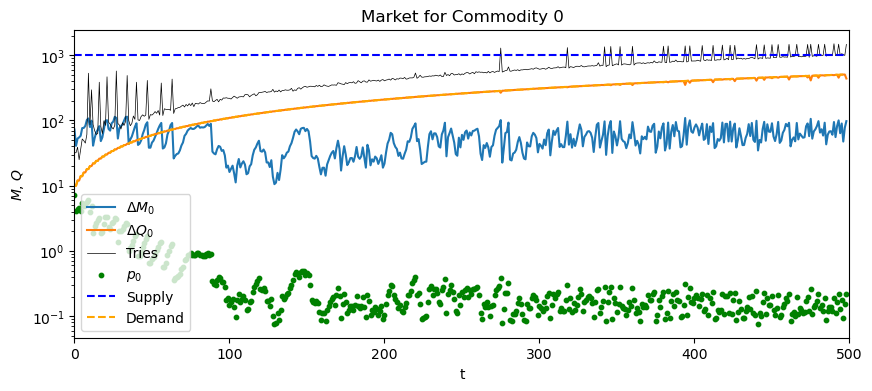

In [16]:
plot_market(0, log=True, supply_demand=True)
plt.xlim(0,T)
#plt.ylim(1e-1, 2e2)

#name = f'method={price_adjust_method} M={M} gam={gamma} eps={epsilon} max_agent_tries={max_agent_tries}'
#plt.savefig('market_plot1 ' + name + '.png')

In [17]:
#QE_df/NB


In [18]:
#plot_market(1, log=True)
#demand_df

In [19]:
np.nanmean(ME_df/QE_df, axis=0)

C:\Users\Alex\AppData\Local\Temp\ipykernel_21204\3985086816.py:1: RuntimeWarning: invalid value encountered in divide
  np.nanmean(ME_df/QE_df, axis=0)
C:\Users\Alex\AppData\Local\Temp\ipykernel_21204\3985086816.py:1: RuntimeWarning: Mean of empty slice
  np.nanmean(ME_df/QE_df, axis=0)


array([0.48573347,        nan])

(0.0, 500.0)

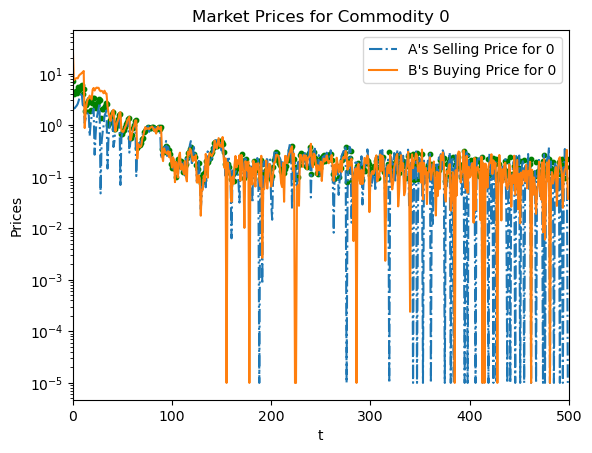

In [20]:
plot_prices(p_df, 0, log=True, includeM=False, A=0, B=NA)
plt.xlim(0,T)
#plt.ylim(1e-1, 2e2)

#name = f'method={price_adjust_method} M={M} gam={gamma} eps={epsilon} max_agent_tries={max_agent_tries}'
#plt.savefig('market_plot2 ' + name + '.png')

(0.0, 500.0)

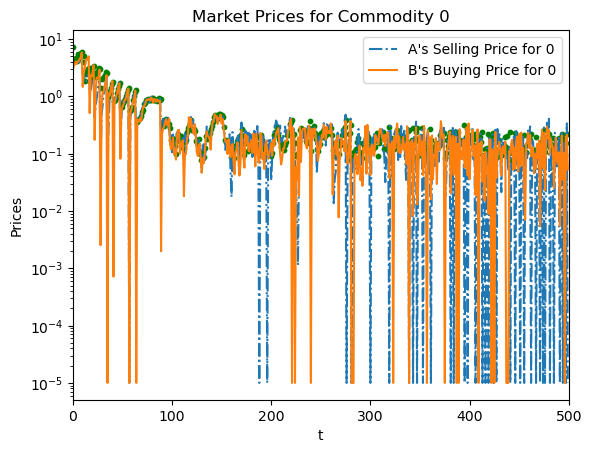

In [21]:
plot_prices(p_df, 0, log=True, includeM=False, A=0+1, B=NA+1)
plt.xlim(0,T)

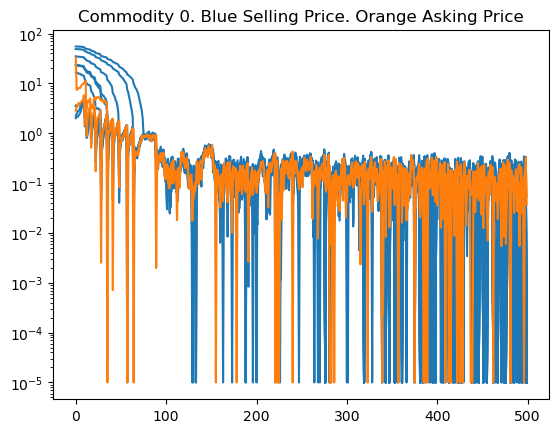

In [22]:
p_buy, p_sell = p_df[0], p_df[1]

for n in range(NA):
    plt.plot(p_sell[:,n][:,0], c='C0')
    #plt.plot(p_buy[:,n][:,0], c='C1')
    
for n in range(NB):
    #plt.plot(p_sell[:,n+NA][:,0], c='C0')
    plt.plot(p_buy[:,n+NA][:,0], c='C1')
    
plt.title('Commodity 0. Blue Selling Price. Orange Asking Price')
plt.yscale('log')

In [23]:
#p_sell[:,11]

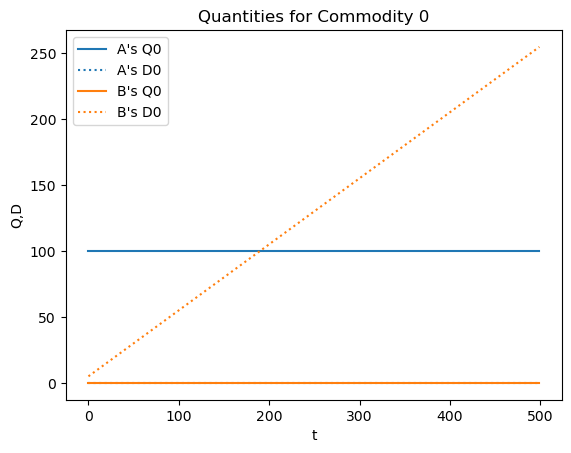

In [24]:
plot_quantities(Q_df, D_df, 0, A=0, B=NA)

In [25]:
#plot_quantities(Q_df, D_df, 0, A=1, B=NA+1)

In [26]:
#market.set_intended_exchange(ExchangeDict)

In [27]:
#market.IntendedExchange

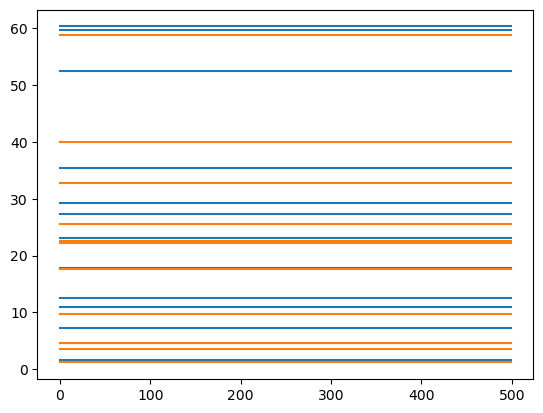

In [28]:
p_buy, p_sell = p_df[0], p_df[1]

for v in range(N):
    plt.plot(p_sell[:,v][:,1], c='C0')
    plt.plot(p_buy[:,v][:,1], c='C1')

In [29]:
#for n in range(NA):
#    plot_quantities(Q_df, D_df, 0, A=n, B=NA+n)

In [30]:
#plot_prices(p_df, 1, log=True, includeM=True, A=0, B=NA)
#plt.grid()

In [31]:
#plot_quantities(Q_df, D_df, 1, A=0, B=NA)

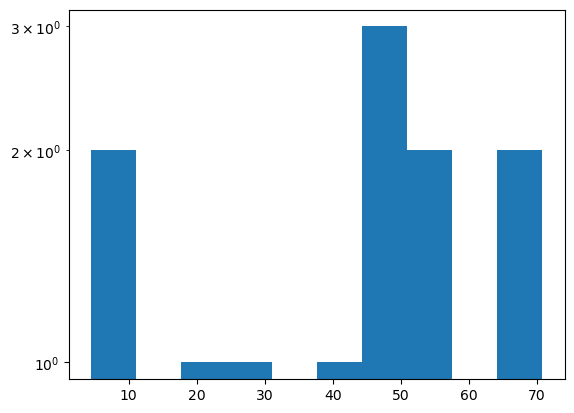

In [32]:
plt.hist([agent.M for agent in agent_list])
plt.yscale('log')

In [33]:
Q = np.zeros(n)
for agent in agent_list:
    Q += agent.Q
    
Q

ValueError: non-broadcastable output operand with shape (1,) doesn't match the broadcast shape (2,)

In [ ]:
Q = np.zeros(n)
for agent in agentA_list:
    Q += agent.Q
    
Q

In [ ]:
for agent in agent_list:
    
    agent.p

In [ ]:
p_buy[:,n][:,1]

In [ ]:
p_buy[:,n]